# 03 · Variable Target — Procesamiento de Fenotipos AMR (v2)

**Objetivo:** Construir el vector de etiquetas `y` para el problema de clasificación binaria
Susceptible (0) vs Resistente (1) a ciprofloxacino en *Klebsiella pneumoniae*.

| Paso | Descripción |
|---|---|
| 1 | Carga de fenotipos brutos + IDs que pasaron el QC genómico |
| 2 | Análisis exploratorio: distribución S/I/R y valores MIC |
| 3 | Diagnóstico de duplicados y exclusión de conflictos S↔R |
| 4 | Validación de consistencia MIC ↔ fenotipo (con signos censurados) |
| 5 | Deduplicación por prioridad (solo genomas sin conflicto) |
| 6 | Resolución de fenotipos Intermedios (I) |
| 7 | Construcción del target binario + análisis de sesgo por fuente |
| 8 | Guardado y verificación de outputs |

**Input:**
- `datos/brutos/amr_fenotipos.csv` — etiquetas S/I/R + MIC por genoma y antibiótico
- `datos/procesados/ids_qc_ok.json` — IDs que superaron el QC (notebook 02)

**Output:**
- `datos/procesados/y_final.npy` — array (N,) con 0=S, 1=R
- `datos/procesados/target_metadata.csv` — genome_id, label, mic_value, mic_sign, fuente_label
- `datos/procesados/informe_target.json` — resumen reproducible del proceso (incluye sesgo fuente)
- `informes/figuras/03_*.png` — figuras EDA del target

---
### Nota sobre breakpoints EUCAST v14 — Ciprofloxacino / *K. pneumoniae*

| Categoría | Criterio MIC (mg/L) | Acción en este pipeline |
|---|---|---|
| S (Susceptible) | ≤ 0.25 | Etiqueta 0 |
| I (Intermedio) | 0.25 < MIC ≤ 0.5 | Ver Celda 6 |
| R (Resistant) | > 0.5 | Etiqueta 1 |

> **EUCAST 2019** eliminó la categoría I tradicional y la redefinió como
> *Susceptible, Increased Exposure* (SIE). En la práctica clínica y en la
> mayoría de los estudios AMR-ML se excluyen o se reclasifican como R
> (enfoque conservador). Este notebook implementa **ambas estrategias** y
> guarda el resultado de la estrategia seleccionada en `y_final.npy`.

---
### Cambios respecto a v1

| Mejora | Motivo |
|---|---|
| Diagnóstico de duplicados S↔R antes de deduplicar | 15 genomas con fenotipo contradictorio resueltos arbitrariamente como S — ahora se excluyen |
| `es_inconsistente()` usa `measurement_sign` | MIC censurados (≤, ≥) se interpretan correctamente |
| Análisis de sesgo `fuente_label` con χ² | Cramér's V=0.278, p<0.0001 — documentado para stratified CV |
| Warning explícito si `ESTRATEGIA_I` no tiene efecto | Dead code silencioso si 0 intermedios post-dedup |
| Fix FutureWarning seaborn boxplot | `hue=` + `legend=False` para compatibilidad con seaborn ≥0.14 |

---
## Celda 0 — Imports y configuración global

In [1]:
# ─── Librería estándar ────────────────────────────────────────────────────────
import json
import logging
from pathlib import Path
from datetime import datetime

# ─── Third-party ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency  # NUEVO v2: test de sesgo por fuente

# ─── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ─── Rutas del proyecto ───────────────────────────────────────────────────────
ROOT      = Path.cwd().parent
DIR_BRUT  = ROOT / "datos" / "brutos"
DIR_PROC  = ROOT / "datos" / "procesados"
DIR_FIGS  = ROOT / "informes" / "figuras"

for d in [DIR_PROC, DIR_FIGS]:
    d.mkdir(parents=True, exist_ok=True)

# ─── Parámetros ───────────────────────────────────────────────────────────────
ANTIBIOTICO = "ciprofloxacin"

# Breakpoints EUCAST v14.0 — Ciprofloxacino / Enterobacterales (K. pneumoniae)
# https://www.eucast.org/clinical_breakpoints/
EUCAST_S_MIC   = 0.25   # S si MIC ≤ 0.25 mg/L
EUCAST_R_MIC   = 0.5    # R si MIC > 0.5 mg/L  (I: 0.25 < MIC ≤ 0.5)

# Estrategia para fenotipos Intermedios:
#   'exclude' → eliminar del dataset (más limpio, menos datos)
#   'as_R'    → reclasificar como Resistente (enfoque conservador clínico)
ESTRATEGIA_I = "exclude"   # ← cambiar aquí si se quiere probar 'as_R'

# Estilo gráfico
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print(f"Proyecto raíz : {ROOT}")
print(f"Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Antibiótico   : {ANTIBIOTICO}")
print(f"Breakpoints   : S ≤ {EUCAST_S_MIC} | I ({EUCAST_S_MIC}–{EUCAST_R_MIC}] | R > {EUCAST_R_MIC} mg/L")
print(f"Estrategia I  : {ESTRATEGIA_I}")

Proyecto raíz : /workspace
Timestamp     : 2026-03-19 14:00:32
Antibiótico   : ciprofloxacin
Breakpoints   : S ≤ 0.25 | I (0.25–0.5] | R > 0.5 mg/L
Estrategia I  : exclude


---
## Celda 1 — Carga de datos

Cargamos el CSV de fenotipos brutos y filtramos por:
1. Antibiótico = ciprofloxacino
2. IDs que pasaron el QC genómico (notebook 02)

In [2]:
# ── 1a. Cargar IDs que pasaron el QC genómico ─────────────────────────────────
ruta_ids = DIR_PROC / "ids_qc_ok.json"
assert ruta_ids.exists(), (
    f"No se encuentra {ruta_ids}\n"
    "→ Ejecuta el notebook 02 (control_calidad_genomica) primero."
)

with open(ruta_ids) as f:
    ids_qc_ok = set(json.load(f))

log.info(f"IDs con QC OK: {len(ids_qc_ok)}")

# ── 1b. Cargar CSV de fenotipos brutos ───────────────────────────────────────
ruta_fenotipos = DIR_BRUT / "amr_fenotipos.csv"
assert ruta_fenotipos.exists(), (
    f"No se encuentra {ruta_fenotipos}\n"
    "→ Ejecuta el notebook 01 (descarga_datos) primero."
)

df_raw = pd.read_csv(ruta_fenotipos, dtype={"genome_id": str})
log.info(f"Fenotipos brutos cargados: {len(df_raw):,} filas, {df_raw.shape[1]} columnas")

print("\nColumnas disponibles:")
print(df_raw.columns.tolist())
print("\nPrimeras filas:")
df_raw.head(3)

14:00:32 [INFO] IDs con QC OK: 565
14:00:32 [INFO] Fenotipos brutos cargados: 10,000 filas, 10 columnas



Columnas disponibles:
['antibiotic', 'resistant_phenotype', 'genome_id', 'genome_name', 'measurement_value', 'laboratory_typing_method', 'testing_standard', 'measurement_unit', 'measurement_sign', 'laboratory_typing_platform']

Primeras filas:


,antibiotic,resistant_phenotype,genome_id,genome_name,measurement_value,laboratory_typing_method,testing_standard,measurement_unit,measurement_sign,laboratory_typing_platform
0,ciprofloxacin,Susceptible,573.10001,Klebsiella pneumoniae strain VRCO0337,NaN,NaN,NaN,NaN,NaN,NaN
1,ciprofloxacin,Susceptible,573.10005,Klebsiella pneumoniae strain VRCO0408,NaN,NaN,NaN,NaN,NaN,NaN
2,ciprofloxacin,Susceptible,573.10008,Klebsiella pneumoniae strain VRCO0411,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── 1c. Filtrar por antibiótico + IDs con QC OK ───────────────────────────────
df_raw["antibiotic"] = df_raw["antibiotic"].str.lower().str.strip()

df_cipro = df_raw[df_raw["antibiotic"] == ANTIBIOTICO].copy()
log.info(f"Registros para {ANTIBIOTICO}: {len(df_cipro):,}")

df_cipro = df_cipro[df_cipro["genome_id"].astype(str).isin(ids_qc_ok)].copy()
log.info(f"Tras filtro QC: {len(df_cipro):,} registros / {df_cipro['genome_id'].nunique()} genomas únicos")

# ── Sanidad: ¿hay genomas con múltiples registros? ──
duplicados = df_cipro.groupby("genome_id").size()
n_dup = (duplicados > 1).sum()

if n_dup > 0:
    log.warning(
        f"{n_dup} genomas tienen >1 registro para {ANTIBIOTICO} "
        "→ se resolverán en Celda 3"
    )
    print(f"\n⚠️  Genomas con registros duplicados: {n_dup}")
    print(duplicados[duplicados > 1].head(10))
else:
    log.info("Sin duplicados — cada genoma tiene exactamente 1 registro")
    print("✓ Sin duplicados")

print(f"\nDistribución de fenotipos (bruta, pre-resolución):")
print(df_cipro["resistant_phenotype"].value_counts())

14:00:32 [INFO] Registros para ciprofloxacin: 10,000
14:00:32 [INFO] Tras filtro QC: 744 registros / 565 genomas únicos
14:00:32 [WARNING] 179 genomas tienen >1 registro para ciprofloxacin → se resolverán en Celda 3



⚠️  Genomas con registros duplicados: 179
genome_id
573.12796    2
573.12863    2
573.12893    2
573.12902    2
573.12912    2
573.12961    2
573.12965    2
573.12969    2
573.12998    2
573.13002    2
dtype: int64

Distribución de fenotipos (bruta, pre-resolución):
resistant_phenotype
Resistant       400
Susceptible     337
Intermediate      7
Name: count, dtype: int64


---
## Celda 2 — EDA del target: distribución de fenotipos y MIC

Antes de tomar ninguna decisión sobre los Intermedios, entendemos el dato:
- ¿Cuántos S/I/R tenemos?
- ¿Qué fracción tiene valor MIC medido?
- ¿La distribución MIC es consistente con los breakpoints EUCAST?

In [4]:
# ── 2a. Distribución S/I/R ────────────────────────────────────────────────────
conteo_sir = df_cipro["resistant_phenotype"].value_counts()
pct_sir    = df_cipro["resistant_phenotype"].value_counts(normalize=True) * 100

print("=" * 45)
print("DISTRIBUCIÓN DE FENOTIPOS (S/I/R)")
print("=" * 45)
for cat in ["Susceptible", "Intermediate", "Resistant"]:
    n   = conteo_sir.get(cat, 0)
    pct = pct_sir.get(cat, 0.0)
    print(f"  {cat:<15}: {n:>4}  ({pct:.1f}%)")
print(f"  {'Total':<15}: {len(df_cipro):>4}")

# Cobertura de MIC
n_con_mic = df_cipro["measurement_value"].notna().sum()
pct_mic   = n_con_mic / len(df_cipro) * 100
print(f"\n  Registros con MIC medido : {n_con_mic} ({pct_mic:.1f}%)")
print(f"  Registros sin MIC        : {len(df_cipro) - n_con_mic}")

DISTRIBUCIÓN DE FENOTIPOS (S/I/R)
  Susceptible    :  337  (45.3%)
  Intermediate   :    7  (0.9%)
  Resistant      :  400  (53.8%)
  Total          :  744

  Registros con MIC medido : 141 (19.0%)
  Registros sin MIC        : 603


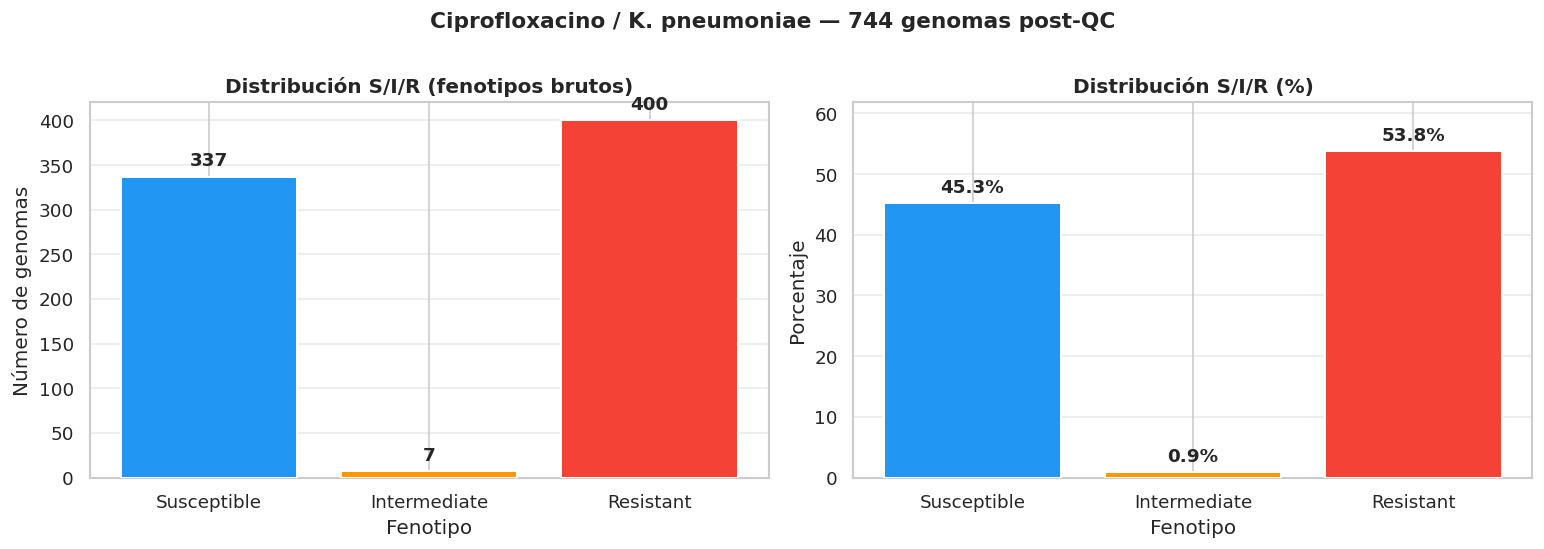

14:00:33 [INFO] Figura guardada → /workspace/informes/figuras/03_distribucion_sir.png


In [5]:
# ── 2b. Figura 1: Barplot S/I/R ───────────────────────────────────────────────
COLORES_SIR = {"Susceptible": "#2196F3", "Intermediate": "#FF9800", "Resistant": "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
categorias = [c for c in ["Susceptible", "Intermediate", "Resistant"] if c in conteo_sir.index]
valores    = [conteo_sir[c] for c in categorias]
colores    = [COLORES_SIR[c] for c in categorias]

bars = ax.bar(categorias, valores, color=colores, edgecolor="white", linewidth=1.2, zorder=3)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=11, fontweight="bold")
ax.set_title("Distribución S/I/R (fenotipos brutos)", fontweight="bold")
ax.set_ylabel("Número de genomas")
ax.set_xlabel("Fenotipo")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

ax2 = axes[1]
pct_vals = [pct_sir.get(c, 0.0) for c in categorias]
bars2    = ax2.bar(categorias, pct_vals, color=colores, edgecolor="white", linewidth=1.2, zorder=3)
ax2.bar_label(bars2, fmt="%.1f%%", padding=4, fontsize=11, fontweight="bold")
ax2.set_title("Distribución S/I/R (%)", fontweight="bold")
ax2.set_ylabel("Porcentaje")
ax2.set_xlabel("Fenotipo")
ax2.set_ylim(0, max(pct_vals) * 1.15)
ax2.grid(axis="y", alpha=0.4, zorder=0)
ax2.set_axisbelow(True)

plt.suptitle(
    f"Ciprofloxacino / K. pneumoniae — {len(df_cipro)} genomas post-QC",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
ruta_fig1 = DIR_FIGS / "03_distribucion_sir.png"
plt.savefig(ruta_fig1, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig1}")

In [6]:
# ── 2c. Distribución de valores MIC ──────────────────────────────────────────
df_mic = df_cipro[df_cipro["measurement_value"].notna()].copy()
df_mic["measurement_value"] = pd.to_numeric(df_mic["measurement_value"], errors="coerce")
df_mic = df_mic[df_mic["measurement_value"].notna()]

print(f"Registros con MIC numérico: {len(df_mic)}")
print("Rangos MIC por categoría:")
print(df_mic.groupby("resistant_phenotype")["measurement_value"].describe().round(3))

print("\nDistribución de measurement_sign:")
print(df_cipro["measurement_sign"].value_counts())

Registros con MIC numérico: 141
Rangos MIC por categoría:
                     count   mean    std   min  25%  50%  75%  max
resistant_phenotype                                               
Intermediate           6.0  2.000  0.000  2.00  2.0  2.0  2.0  2.0
Resistant            115.0  2.896  2.062  1.00  2.0  2.0  2.0  8.0
Susceptible           20.0  0.575  0.231  0.25  0.5  0.5  0.5  1.0

Distribución de measurement_sign:
measurement_sign
>     109
<=     16
>=      5
=       3
<       1
Name: count, dtype: int64


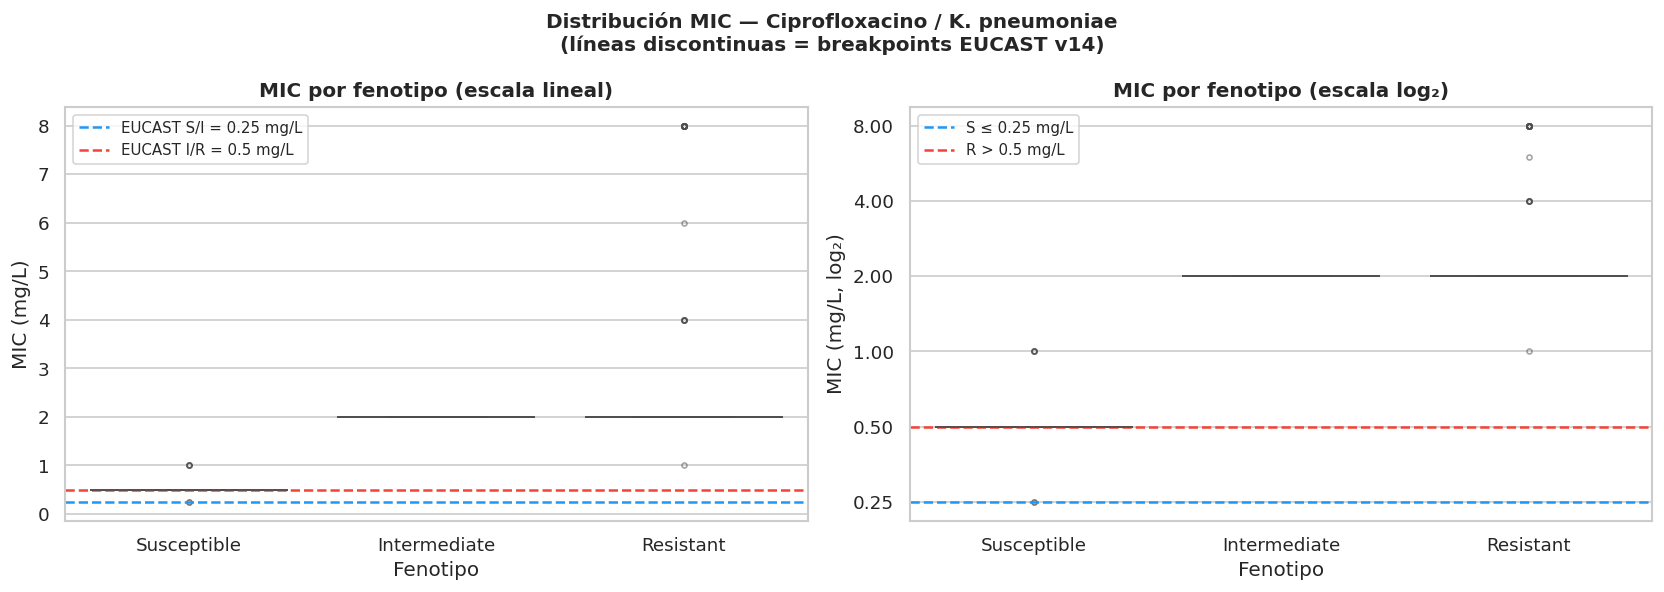

14:00:34 [INFO] Figura guardada → /workspace/informes/figuras/03_mic_por_fenotipo.png


In [7]:
# ── 2d. Figura 2: Boxplot MIC por fenotipo + breakpoints EUCAST ──────────────
# FIX v2: hue= + legend=False para compatibilidad seaborn ≥0.14
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = [c for c in ["Susceptible", "Intermediate", "Resistant"] if c in df_mic["resistant_phenotype"].unique()]

ax = axes[0]
sns.boxplot(
    data=df_mic, x="resistant_phenotype", y="measurement_value",
    order=orden, hue="resistant_phenotype", palette=COLORES_SIR,
    legend=False, ax=ax,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5}
)
ax.axhline(EUCAST_S_MIC, color="#2196F3", linestyle="--", lw=1.5,
           label=f"EUCAST S/I = {EUCAST_S_MIC} mg/L")
ax.axhline(EUCAST_R_MIC, color="#F44336", linestyle="--", lw=1.5,
           label=f"EUCAST I/R = {EUCAST_R_MIC} mg/L")
ax.set_title("MIC por fenotipo (escala lineal)", fontweight="bold")
ax.set_xlabel("Fenotipo")
ax.set_ylabel("MIC (mg/L)")
ax.legend(fontsize=9)

ax2 = axes[1]
sns.boxplot(
    data=df_mic, x="resistant_phenotype", y="measurement_value",
    order=orden, hue="resistant_phenotype", palette=COLORES_SIR,
    legend=False, ax=ax2,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5}
)
ax2.set_yscale("log", base=2)
ax2.axhline(EUCAST_S_MIC, color="#2196F3", linestyle="--", lw=1.5,
            label=f"S ≤ {EUCAST_S_MIC} mg/L")
ax2.axhline(EUCAST_R_MIC, color="#F44336", linestyle="--", lw=1.5,
            label=f"R > {EUCAST_R_MIC} mg/L")
ax2.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax2.set_title("MIC por fenotipo (escala log₂)", fontweight="bold")
ax2.set_xlabel("Fenotipo")
ax2.set_ylabel("MIC (mg/L, log₂)")
ax2.legend(fontsize=9)

plt.suptitle(
    "Distribución MIC — Ciprofloxacino / K. pneumoniae\n"
    "(líneas discontinuas = breakpoints EUCAST v14)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
ruta_fig2 = DIR_FIGS / "03_mic_por_fenotipo.png"
plt.savefig(ruta_fig2, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig2}")

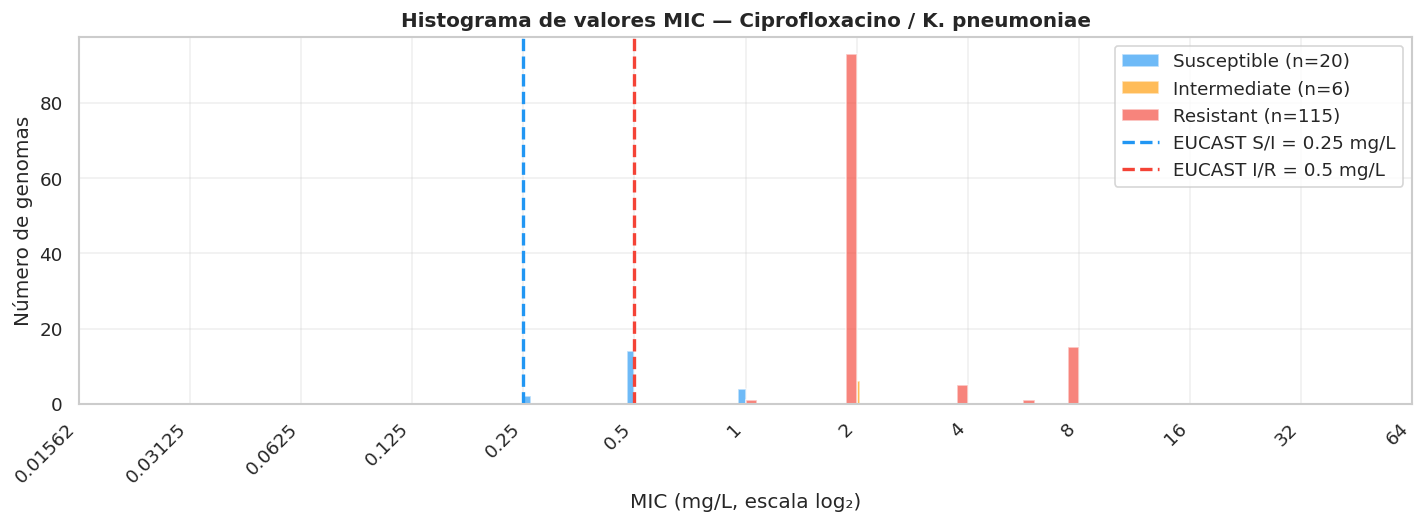

14:00:34 [INFO] Figura guardada → /workspace/informes/figuras/03_histograma_mic.png


In [8]:
# ── 2e. Figura 3: Histograma de diluciones MIC ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))

for cat, color in COLORES_SIR.items():
    sub = df_mic[df_mic["resistant_phenotype"] == cat]["measurement_value"]
    if len(sub) == 0:
        continue
    ax.hist(
        np.log2(sub + 1e-6),
        bins=30, alpha=0.65, color=color,
        label=f"{cat} (n={len(sub)})", edgecolor="white"
    )

ax.axvline(np.log2(EUCAST_S_MIC), color="#2196F3", linestyle="--", lw=2,
           label=f"EUCAST S/I = {EUCAST_S_MIC} mg/L")
ax.axvline(np.log2(EUCAST_R_MIC), color="#F44336", linestyle="--", lw=2,
           label=f"EUCAST I/R = {EUCAST_R_MIC} mg/L")

ticks_log2 = np.arange(-6, 7, dtype=float)
ax.set_xticks(ticks_log2)
ax.set_xticklabels([f"{2**t:.4g}" for t in ticks_log2], rotation=45, ha="right")

ax.set_xlabel("MIC (mg/L, escala log₂)")
ax.set_ylabel("Número de genomas")
ax.set_title("Histograma de valores MIC — Ciprofloxacino / K. pneumoniae", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
ruta_fig3 = DIR_FIGS / "03_histograma_mic.png"
plt.savefig(ruta_fig3, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig3}")

---
## Celda 3 — Diagnóstico de duplicados y exclusión de conflictos S↔R

**NUEVO en v2.** Antes de deduplicar, clasificamos los genomas con múltiples
registros según el tipo de conflicto:

| Tipo | Descripción | Acción |
|---|---|---|
| `concordante` | Todos los registros coinciden (S+S, R+R) | Deduplicar normalmente |
| `S+R conflicto` | Un registro dice S, otro dice R | **Excluir** — etiqueta no fiable |
| `S+I mixto` | Susceptible + Intermediate | Deduplicar (prioridad S > I) |
| `R+I mixto` | Resistant + Intermediate | Deduplicar (prioridad R > I) |

**Justificación:** Si dos ensayos de laboratorio independientes dan resultados
opuestos para el mismo aislado y antibiótico, no hay dato adicional que permita
desambiguar. Resolver como S (prioridad arbitraria de v1) introduce sesgo
sistemático hacia falsos negativos.

In [9]:
# ── 3a. Clasificar tipos de duplicados ─────────────────────────────────────────
duplicados_ids = df_cipro.groupby("genome_id").filter(lambda g: len(g) > 1)["genome_id"].unique()

conflictos = []
for gid in duplicados_ids:
    fenotipos = set(df_cipro[df_cipro["genome_id"] == gid]["resistant_phenotype"])
    if {"Susceptible", "Resistant"} <= fenotipos:
        tipo = "S+R conflicto"
    elif {"Susceptible", "Intermediate"} <= fenotipos:
        tipo = "S+I mixto"
    elif {"Resistant", "Intermediate"} <= fenotipos:
        tipo = "R+I mixto"
    else:
        tipo = "concordante"
    conflictos.append({"genome_id": gid, "fenotipos": fenotipos, "tipo": tipo})

df_conflictos = pd.DataFrame(conflictos)

print("Distribución de tipos de duplicados:")
print(df_conflictos["tipo"].value_counts())

n_sr = (df_conflictos["tipo"] == "S+R conflicto").sum()
print(f"\nGenomas con conflicto S↔R directo: {n_sr}")

# ── 3b. Excluir genomas con conflicto S↔R ────────────────────────────────────
ids_conflicto_sr = set(
    df_conflictos[df_conflictos["tipo"] == "S+R conflicto"]["genome_id"]
)

if ids_conflicto_sr:
    n_antes = len(df_cipro)
    df_cipro = df_cipro[~df_cipro["genome_id"].isin(ids_conflicto_sr)].copy()
    log.warning(
        f"{len(ids_conflicto_sr)} genomas con fenotipo contradictorio S↔R "
        f"excluidos ({n_antes} → {len(df_cipro)} registros)"
    )
    print(f"\n⚠️  {len(ids_conflicto_sr)} genomas excluidos por conflicto S↔R")
else:
    print("✓ Sin conflictos S↔R")

print(f"\nRegistros restantes: {len(df_cipro):,}")
print(f"Genomas únicos restantes: {df_cipro['genome_id'].nunique()}")

14:00:34 [WARNING] 15 genomas con fenotipo contradictorio S↔R excluidos (744 → 714 registros)


Distribución de tipos de duplicados:
tipo
concordante      157
S+R conflicto     15
S+I mixto          6
R+I mixto          1
Name: count, dtype: int64

Genomas con conflicto S↔R directo: 15

⚠️  15 genomas excluidos por conflicto S↔R

Registros restantes: 714
Genomas únicos restantes: 550


---
## Celda 4 — Validación de consistencia MIC ↔ fenotipo

Detectamos genomas en los que el valor MIC reportado **contradice** el fenotipo S/R
asignado según los breakpoints EUCAST.

**NUEVO en v2:** La función `es_inconsistente()` ahora tiene en cuenta el campo
`measurement_sign` (=, <=, >=) para interpretar correctamente MICs censurados.
Un MIC ≤ 1.0 mg/L con fenotipo Susceptible ya no se marca como inconsistente,
porque el valor real podría estar por debajo de 0.25 mg/L.

In [10]:
# ── 4a. Detectar inconsistencias MIC ↔ fenotipo ───────────────────────────────
# FIX v2: measurement_sign ahora se usa en la lógica de inconsistencia

df_val = df_mic[df_mic["resistant_phenotype"].isin(["Susceptible", "Resistant"])].copy()

def es_inconsistente(row):
    """True si el MIC contradice el fenotipo según breakpoints EUCAST,
    teniendo en cuenta el signo de censura del ensayo."""
    mic   = row["measurement_value"]
    fenot = row["resistant_phenotype"]
    signo = str(row.get("measurement_sign", "=")).strip()

    if pd.isna(mic):
        return False

    if fenot == "Susceptible":
        if signo == ">=":
            # MIC >= X: valor real podría ser mayor → si X > EUCAST_R_MIC, inconsistente
            return mic > EUCAST_R_MIC
        elif signo == "<=":
            # MIC <= X: valor real podría ser menor → no se puede afirmar inconsistencia
            return False
        else:  # "=" o NaN
            return mic > EUCAST_R_MIC

    if fenot == "Resistant":
        if signo == "<=":
            return mic <= EUCAST_S_MIC
        elif signo == ">=":
            return False
        else:
            return mic <= EUCAST_S_MIC

    return False

df_val["inconsistente"] = df_val.apply(es_inconsistente, axis=1)

n_inc = df_val["inconsistente"].sum()
ids_inconsistentes = set(df_val[df_val["inconsistente"]]["genome_id"].astype(str))

print(f"Genomas con MIC numérico y fenotipo S/R: {len(df_val)}")
print(f"Inconsistencias MIC↔fenotipo detectadas: {n_inc}")

if n_inc > 0:
    print("\nDetalle de inconsistencias:")
    cols_show = ["genome_id", "resistant_phenotype", "measurement_value", "measurement_sign"]
    print(df_val[df_val["inconsistente"]][cols_show].to_string(index=False))
else:
    print("✓ Sin inconsistencias MIC↔fenotipo")

Genomas con MIC numérico y fenotipo S/R: 135
Inconsistencias MIC↔fenotipo detectadas: 3

Detalle de inconsistencias:
genome_id resistant_phenotype  measurement_value measurement_sign
573.13705         Susceptible                1.0              NaN
573.14201         Susceptible                1.0              NaN
573.24279         Susceptible                1.0                =


---
## Celda 5 — Deduplicación por prioridad

Ahora que los conflictos S↔R ya están excluidos, la deduplicación solo resuelve
redundancias (S+S, R+R) y mixtos S+I o R+I.

Prioridad de fuente (de mayor a menor confianza):
1. Fenotipo S/R con MIC numérico consistente con EUCAST
2. Fenotipo S/R sin MIC (solo categoría clínica)
3. Fenotipo Intermediate (se resolverá en Celda 6)

In [11]:
# ── 5a. Deduplicar genomas con múltiples registros ────────────────────────────
# NOTA v2: Los conflictos S↔R ya fueron excluidos en Celda 3.

def prioridad_fenotipo(fenot):
    return {"Susceptible": 0, "Resistant": 1, "Intermediate": 2}.get(fenot, 3)

df_cipro["_prioridad"] = df_cipro["resistant_phenotype"].map(prioridad_fenotipo)

df_dedup = (
    df_cipro
    .sort_values(["genome_id", "_prioridad"])
    .drop_duplicates(subset="genome_id", keep="first")
    .drop(columns=["_prioridad"])
    .reset_index(drop=True)
)

log.info(f"Tras deduplicación: {len(df_dedup)} genomas únicos")
print(f"Genomas únicos en df_dedup: {len(df_dedup)}")
print(f"\nDistribución S/I/R post-dedup:")
print(df_dedup["resistant_phenotype"].value_counts())

14:00:35 [INFO] Tras deduplicación: 550 genomas únicos


Genomas únicos en df_dedup: 550

Distribución S/I/R post-dedup:
resistant_phenotype
Susceptible    275
Resistant      275
Name: count, dtype: int64


---
## Celda 6 — Resolución de fenotipos Intermedios

| Estrategia | Descripción | Ventaja | Riesgo |
|---|---|---|---|
| `exclude` | Eliminar los I del dataset | Etiquetas más limpias | Pierde datos |
| `as_R` | Reclasificar I → Resistente | Máxima seguridad clínica | Introduce ruido |

**Referencia:** EUCAST 2019 redefinió I como *Susceptible, Increased Exposure* (SIE).

In [12]:
# ── 6a. Aplicar estrategia para Intermedios ────────────────────────────────────
n_intermedios = (df_dedup["resistant_phenotype"] == "Intermediate").sum()
print(f"Fenotipos Intermedios a resolver: {n_intermedios}")

# FIX v2: Warning explícito si la estrategia no tiene efecto real
if n_intermedios == 0:
    log.warning(
        f"ESTRATEGIA_I='{ESTRATEGIA_I}' no tiene efecto: 0 intermedios "
        "post-deduplicación. Los I originales fueron absorbidos por "
        "registros S/R en la deduplicación."
    )

if ESTRATEGIA_I == "exclude":
    df_final = df_dedup[df_dedup["resistant_phenotype"] != "Intermediate"].copy()
    log.info(f"Estrategia 'exclude': {n_intermedios} genomas eliminados")
elif ESTRATEGIA_I == "as_R":
    df_final = df_dedup.copy()
    mask_i = df_final["resistant_phenotype"] == "Intermediate"
    df_final.loc[mask_i, "resistant_phenotype"] = "Resistant"
    log.info(f"Estrategia 'as_R': {n_intermedios} Intermedios reclasificados como Resistant")
else:
    raise ValueError(f"ESTRATEGIA_I desconocida: {ESTRATEGIA_I!r}. Usa 'exclude' o 'as_R'.")

# ── 6b. Excluir genomas con inconsistencia MIC↔fenotipo ───────────────────────
n_antes_exc = len(df_final)
df_final = df_final[~df_final["genome_id"].astype(str).isin(ids_inconsistentes)].copy()
n_excluidos_inc = n_antes_exc - len(df_final)

log.info(f"Genomas excluidos por inconsistencia MIC↔fenotipo: {n_excluidos_inc}")

print(f"\n{'─'*40}")
print(f"Genomas en df_final: {len(df_final)}")
print(f"  Excluidos por conflicto S↔R          : {len(ids_conflicto_sr)}")
print(f"  Excluidos por estrategia '{ESTRATEGIA_I}': {n_intermedios if ESTRATEGIA_I == 'exclude' else 0}")
print(f"  Excluidos por inconsistencia MIC↔feno : {n_excluidos_inc}")
print(f"\nDistribución final S/R:")
print(df_final["resistant_phenotype"].value_counts())

# Ratio desbalance
vc = df_final["resistant_phenotype"].value_counts(normalize=True)
ratio_max = vc.max()
print(f"\nRatio mayoritaria/minoritaria: {ratio_max:.2f}")
if ratio_max > 0.65:
    print("⚠️  Desbalance notable (>65%) — usar class_weight='balanced' o scale_pos_weight en modelado")
else:
    print("✓ Clases razonablemente balanceadas")

14:00:35 [WARNING] ESTRATEGIA_I='exclude' no tiene efecto: 0 intermedios post-deduplicación. Los I originales fueron absorbidos por registros S/R en la deduplicación.
14:00:35 [INFO] Estrategia 'exclude': 0 genomas eliminados
14:00:35 [INFO] Genomas excluidos por inconsistencia MIC↔fenotipo: 3


Fenotipos Intermedios a resolver: 0

────────────────────────────────────────
Genomas en df_final: 547
  Excluidos por conflicto S↔R          : 15
  Excluidos por estrategia 'exclude': 0
  Excluidos por inconsistencia MIC↔feno : 3

Distribución final S/R:
resistant_phenotype
Resistant      275
Susceptible    272
Name: count, dtype: int64

Ratio mayoritaria/minoritaria: 0.50
✓ Clases razonablemente balanceadas


---
## Celda 7 — Construcción del target binario + análisis de sesgo por fuente

Codificamos el target como entero:
- `0` → Susceptible
- `1` → Resistant

**NUEVO en v2:** Análisis de sesgo entre genomas con MIC medido vs solo fenotipo.
Cramér's V y test χ² para documentar la diferencia de distribución S/R entre fuentes.

In [13]:
# ── 7a. Crear tabla de metadata del target ────────────────────────────────────
COLS_META = [
    "genome_id", "resistant_phenotype", "measurement_value",
    "measurement_sign", "measurement_units", "laboratory_typing_method", "source",
]
cols_disponibles = [c for c in COLS_META if c in df_final.columns]

df_meta = df_final[cols_disponibles].copy()
df_meta["genome_id"] = df_meta["genome_id"].astype(str)

# Etiqueta binaria
df_meta["label"] = df_meta["resistant_phenotype"].map(
    {"Susceptible": 0, "Resistant": 1}
).astype(int)

# Fuente de la etiqueta
df_meta["fuente_label"] = np.where(
    df_meta["measurement_value"].notna(), "MIC+fenotipo", "solo_fenotipo"
)

df_meta = df_meta.reset_index(drop=True)

print(f"Shape df_meta: {df_meta.shape}")
print(f"\nDistribución de labels:")
print(df_meta["label"].value_counts().rename({0: "0 (S)", 1: "1 (R)"}))
print(f"\nFuente de etiqueta:")
print(df_meta["fuente_label"].value_counts())
print(f"\nPrimeras filas de df_meta:")
df_meta.head()

Shape df_meta: (547, 7)

Distribución de labels:
label
1 (R)    275
0 (S)    272
Name: count, dtype: int64

Fuente de etiqueta:
fuente_label
solo_fenotipo    480
MIC+fenotipo      67
Name: count, dtype: int64

Primeras filas de df_meta:


,genome_id,resistant_phenotype,measurement_value,measurement_sign,laboratory_typing_method,label,fuente_label
0,573.10076,Susceptible,NaN,NaN,NaN,0,solo_fenotipo
1,573.10077,Susceptible,NaN,NaN,NaN,0,solo_fenotipo
2,573.10085,Susceptible,NaN,NaN,NaN,0,solo_fenotipo
3,573.12461,Resistant,NaN,NaN,NaN,1,solo_fenotipo
4,573.12465,Resistant,NaN,NaN,NaN,1,solo_fenotipo


In [14]:
# ── 7b. Análisis de sesgo por fuente de etiqueta ──────────────────────────────
# NUEVO v2: Test χ² para detectar diferencias en la distribución S/R

ct = pd.crosstab(df_meta["fuente_label"], df_meta["label"])
chi2, p_value, dof, expected = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / len(df_meta))

print("Tabla de contingencia fuente × label:")
print(ct)
print(f"\nχ² = {chi2:.3f}, p = {p_value:.2e}")
print(f"Tamaño efecto (Cramér's V): {cramers_v:.3f}")

for fuente in ["MIC+fenotipo", "solo_fenotipo"]:
    sub = df_meta[df_meta["fuente_label"] == fuente]
    pct_r = (sub["label"] == 1).mean() * 100
    print(f"  {fuente:<16}: {len(sub):>4} genomas, {pct_r:.1f}% R")

if p_value < 0.05:
    print("\n⚠️  Distribución S/R significativamente diferente entre fuentes")
    print("   → Usar stratified split por fuente_label en validación cruzada (notebook 06)")
    print("   → Reportar métricas por fuente en análisis de errores (notebook 07/08)")
else:
    print("\n✓ Sin evidencia de sesgo de anotación entre fuentes")

# Guardar para uso downstream
sesgo_fuente = {
    "chi2": float(chi2),
    "p_value": float(p_value),
    "cramers_v": float(cramers_v),
    "pct_R_mic_fenotipo": float(
        (df_meta[df_meta["fuente_label"] == "MIC+fenotipo"]["label"] == 1).mean() * 100
    ),
    "pct_R_solo_fenotipo": float(
        (df_meta[df_meta["fuente_label"] == "solo_fenotipo"]["label"] == 1).mean() * 100
    ),
    "accion_recomendada": "stratified_split_por_fuente_en_CV"
}

Tabla de contingencia fuente × label:
label            0    1
fuente_label           
MIC+fenotipo     9   58
solo_fenotipo  263  217

χ² = 38.592, p = 5.22e-10
Tamaño efecto (Cramér's V): 0.266
  MIC+fenotipo    :   67 genomas, 86.6% R
  solo_fenotipo   :  480 genomas, 45.2% R

⚠️  Distribución S/R significativamente diferente entre fuentes
   → Usar stratified split por fuente_label en validación cruzada (notebook 06)
   → Reportar métricas por fuente en análisis de errores (notebook 07/08)


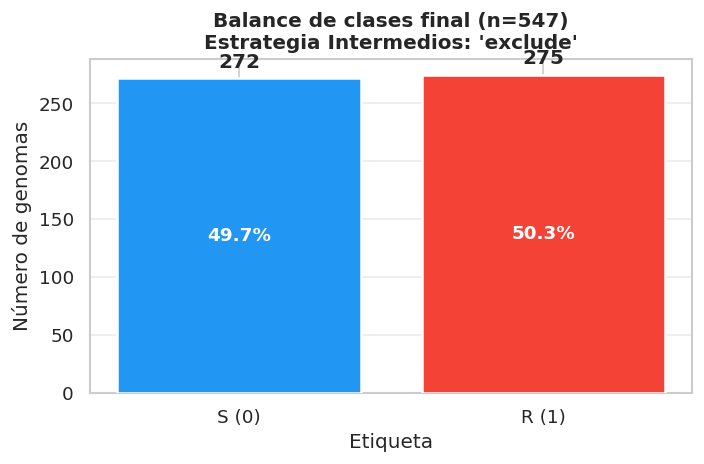

14:00:35 [INFO] Figura guardada → /workspace/informes/figuras/03_balance_clases_final.png


In [15]:
# ── 7c. Figura 4: Balance de clases final ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

vc_label = df_meta["label"].value_counts().sort_index()
colores_bin = ["#2196F3", "#F44336"]
barras = ax.bar(
    ["S (0)", "R (1)"],
    vc_label.values,
    color=colores_bin, edgecolor="white", linewidth=1.5, zorder=3
)
ax.bar_label(barras, fmt="%d", padding=4, fontsize=12, fontweight="bold")

total = vc_label.sum()
for i, (bar, val) in enumerate(zip(barras, vc_label.values)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{val/total*100:.1f}%",
        ha="center", va="center", fontsize=11, color="white", fontweight="bold"
    )

ax.set_title(
    f"Balance de clases final (n={total})\n"
    f"Estrategia Intermedios: '{ESTRATEGIA_I}'",
    fontweight="bold"
)
ax.set_ylabel("Número de genomas")
ax.set_xlabel("Etiqueta")
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
ruta_fig4 = DIR_FIGS / "03_balance_clases_final.png"
plt.savefig(ruta_fig4, bbox_inches="tight", dpi=150)
plt.show()
log.info(f"Figura guardada → {ruta_fig4}")

In [16]:
# ── 7d. Sanity check final ───────────────────────────────────────────────────
assert df_meta["label"].isna().sum() == 0, "❌ Hay NaN en label"
assert set(df_meta["label"].unique()) <= {0, 1}, "❌ Valores fuera de {0, 1} en label"
assert df_meta["genome_id"].nunique() == len(df_meta), "❌ Genome IDs duplicados"
assert df_meta["genome_id"].isin(ids_qc_ok).all(), "❌ Hay IDs no presentes en ids_qc_ok"

print("✓ Todos los sanity checks superados")
print(f"  → {len(df_meta)} genomas con etiqueta binaria limpia")
print(f"  → Susceptible: {(df_meta['label']==0).sum()} | Resistant: {(df_meta['label']==1).sum()}")

✓ Todos los sanity checks superados
  → 547 genomas con etiqueta binaria limpia
  → Susceptible: 272 | Resistant: 275


---
## Celda 8 — Guardado de outputs

| Archivo | Descripción | Consumidor |
|---|---|---|
| `y_final.npy` | Array (N,) int — etiquetas 0/1 | notebooks 06, 07, 08 |
| `target_metadata.csv` | Tabla genome_id ↔ label ↔ MIC ↔ fuente | notebooks 05, 06, 09 |
| `informe_target.json` | Resumen reproducible + sesgo fuente + conflictos | auditoría |

> **Orden crítico:** La posición i-ésima de `y_final.npy` corresponde al
> `genome_id` en la fila i de `target_metadata.csv`. El notebook 05
> (matriz_features) **debe respetar este orden** al construir X.

In [17]:
# ── 8a. Guardar y_final.npy ───────────────────────────────────────────────────
y_final = df_meta["label"].to_numpy(dtype=np.int8)

ruta_y = DIR_PROC / "y_final.npy"
np.save(ruta_y, y_final)
log.info(f"y_final.npy guardado → {ruta_y}  shape={y_final.shape}  dtype={y_final.dtype}")

# ── 8b. Guardar target_metadata.csv ──────────────────────────────────────────
ruta_meta = DIR_PROC / "target_metadata.csv"
df_meta.to_csv(ruta_meta, index=False)
log.info(f"target_metadata.csv guardado → {ruta_meta}  shape={df_meta.shape}")

# ── 8c. Guardar informe JSON (v2: incluye sesgo_fuente y conflictos_sr) ──────
vc_final = {int(k): int(v) for k, v in df_meta["label"].value_counts().to_dict().items()}

informe = {
    "timestamp"             : datetime.now().isoformat(),
    "version_notebook"      : "v2",
    "antibiotico"           : ANTIBIOTICO,
    "breakpoints_eucast"    : {
        "version"           : "v14.0",
        "organismo"         : "Klebsiella pneumoniae",
        "S_mic_leq"         : float(EUCAST_S_MIC),
        "R_mic_gt"          : float(EUCAST_R_MIC),
        "unidades"          : "mg/L"
    },
    "estrategia_intermedios": ESTRATEGIA_I,
    "n_total_input"         : int(len(df_cipro)),
    "n_conflictos_sr"       : int(len(ids_conflicto_sr)),
    "n_intermedios"         : int(n_intermedios),
    "n_inconsistentes_mic"  : int(n_excluidos_inc),
    "n_final"               : int(len(df_meta)),
    "distribucion_final"    : {
        "Susceptible (0)"   : vc_final.get(0, 0),
        "Resistant (1)"     : vc_final.get(1, 0),
    },
    "pct_con_mic"           : float(round(df_meta["measurement_value"].notna().mean() * 100, 1)),
    "sesgo_fuente"          : sesgo_fuente,
    "archivos": {
        "y_final"           : str(ruta_y),
        "target_metadata"   : str(ruta_meta),
    }
}

ruta_inf = DIR_PROC / "informe_target.json"
with open(ruta_inf, "w") as f:
    json.dump(informe, f, indent=2, ensure_ascii=False)

print(json.dumps(informe, indent=2, ensure_ascii=False))
log.info(f"Informe guardado → {ruta_inf}")

14:00:35 [INFO] y_final.npy guardado → /workspace/datos/procesados/y_final.npy  shape=(547,)  dtype=int8
14:00:35 [INFO] target_metadata.csv guardado → /workspace/datos/procesados/target_metadata.csv  shape=(547, 7)
14:00:35 [INFO] Informe guardado → /workspace/datos/procesados/informe_target.json


{
  "timestamp": "2026-03-19T14:00:35.586911",
  "version_notebook": "v2",
  "antibiotico": "ciprofloxacin",
  "breakpoints_eucast": {
    "version": "v14.0",
    "organismo": "Klebsiella pneumoniae",
    "S_mic_leq": 0.25,
    "R_mic_gt": 0.5,
    "unidades": "mg/L"
  },
  "estrategia_intermedios": "exclude",
  "n_total_input": 714,
  "n_conflictos_sr": 15,
  "n_intermedios": 0,
  "n_inconsistentes_mic": 3,
  "n_final": 547,
  "distribucion_final": {
    "Susceptible (0)": 272,
    "Resistant (1)": 275
  },
  "pct_con_mic": 12.2,
  "sesgo_fuente": {
    "chi2": 38.59151712558115,
    "p_value": 5.224550323132178e-10,
    "cramers_v": 0.2656147955367122,
    "pct_R_mic_fenotipo": 86.56716417910447,
    "pct_R_solo_fenotipo": 45.208333333333336,
    "accion_recomendada": "stratified_split_por_fuente_en_CV"
  },
  "archivos": {
    "y_final": "/workspace/datos/procesados/y_final.npy",
    "target_metadata": "/workspace/datos/procesados/target_metadata.csv"
  }
}


---
## Celda 9 — Verificación de los archivos guardados

Carga inmediata para confirmar que los archivos se escribieron y leen correctamente.

In [18]:
# ── Verificación de integridad post-guardado ──────────────────────────────────
y_check    = np.load(DIR_PROC / "y_final.npy")
meta_check = pd.read_csv(DIR_PROC / "target_metadata.csv", dtype={"genome_id": str})

print("── y_final.npy ──────────────────────────────────────")
print(f"  shape  : {y_check.shape}")
print(f"  dtype  : {y_check.dtype}")
print(f"  únicos : {np.unique(y_check, return_counts=True)}")

print("\n── target_metadata.csv ──────────────────────────────")
print(f"  shape     : {meta_check.shape}")
print(f"  columnas  : {meta_check.columns.tolist()}")

assert len(y_check) == len(meta_check), "❌ Longitud no coincide"
assert (y_check == meta_check["label"].to_numpy()).all(), "❌ Desalineación entre y y metadata"

print("\n✓ y_final.npy y target_metadata.csv correctamente alineados")
print(f"\n{'='*50}")
print("RESUMEN DEL NOTEBOOK 03 (v2)")
print(f"{'='*50}")
print(f"  Genomas de entrada (post-QC)   : {len(ids_qc_ok)}")
print(f"  Conflictos S↔R excluidos       : {len(ids_conflicto_sr)}")
print(f"  Intermedios ({ESTRATEGIA_I:<7})        : {n_intermedios}")
print(f"  Inconsistencias MIC↔fenotipo   : {n_excluidos_inc}")
print(f"  Dataset final                  : {len(y_check)} genomas")
print(f"    Susceptible (0)              : {(y_check == 0).sum()}")
print(f"    Resistant   (1)              : {(y_check == 1).sum()}")
print(f"  Sesgo fuente (Cramér's V)     : {sesgo_fuente['cramers_v']:.3f}")
print(f"\n  Siguiente paso → notebook 04: extracción de k-mers")

── y_final.npy ──────────────────────────────────────
  shape  : (547,)
  dtype  : int8
  únicos : (array([0, 1], dtype=int8), array([272, 275]))

── target_metadata.csv ──────────────────────────────
  shape     : (547, 7)
  columnas  : ['genome_id', 'resistant_phenotype', 'measurement_value', 'measurement_sign', 'laboratory_typing_method', 'label', 'fuente_label']

✓ y_final.npy y target_metadata.csv correctamente alineados

RESUMEN DEL NOTEBOOK 03 (v2)
  Genomas de entrada (post-QC)   : 565
  Conflictos S↔R excluidos       : 15
  Intermedios (exclude)        : 0
  Inconsistencias MIC↔fenotipo   : 3
  Dataset final                  : 547 genomas
    Susceptible (0)              : 272
    Resistant   (1)              : 275
  Sesgo fuente (Cramér's V)     : 0.266

  Siguiente paso → notebook 04: extracción de k-mers
